# SIT720 11.1 HD — Machine Learning Mini Research


**Name:** Sagar Sagar
**Student ID:** S225661935
**Email:** S225661935@deakin.edu.au


**GenAI acknowledgement**: Claude (Anthropic) was used to troubleshoot coding errors during the assignment.

## Part 1 — Understanding and Reproducing Published Machine Learning Results

### (i) Research problem, motivation, SOTA and gap
Heart disease is a major cause of death worldwide, making early and accurate risk prediction important for supporting timely clinical intervention. Previous studies have used classifiers such as Logistic Regression (LR), Decision Tree (DT), Random Forest (RF), SVM, Naive Bayes (NB), KNN and XGBoost on different versions of the UCI/Cleveland heart-disease dataset. Reported accuracy has generally been around 85–93%, although some studies achieved higher results, such as Ghosh et al.'s Relief-selected RF at 97.89%. The paper identifies a limitation in relying on individual classifiers and proposes a 5-fold stacking ensemble combining six base classifiers (LR, NB, KNN, DT, RF and XGBoost). The proposed ensemble reports an accuracy of 98.53%, which is higher than the individual-classifier results compared in the paper.

### (ii) Dataset and feature set
The study uses the Kaggle "Heart Disease Dataset" (johnsmith88/heart-disease-dataset), which combines data from the Cleveland, Hungary, Switzerland and Long Beach V databases. The dataset contains 1,025 records and uses the same 14 attributes as the processed Cleveland dataset: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal and target.

### (iii)-(iv) Methods, protocol and metrics
Six classifiers are evaluated: Logistic Regression, Naive Bayes, KNN, Decision Tree, Random Forest and XGBoost. The evaluation uses Accuracy, Precision, Recall/Sensitivity, F1-score, Specificity, MCC and AUC. The six models are then combined using a 5-fold stacking ensemble with a meta-classifier.

The paper does not clearly specify the train/test split ratio or the hyperparameters used for each classifier. Therefore, following the assignment's reasonable-assumptions guideline, an 80/20 stratified split with `random_state=42` and the default library hyperparameters are used for the reproduction. This provides a consistent and reproducible setup for comparing the individual models and the stacking ensemble.


In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, matthews_corrcoef, roc_curve)
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
RS = 42

df = pd.read_csv('heart.csv')
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df['target'].value_counts())

Dataset shape: (1025, 14)
Missing values: 0
target
1    526
0    499
Name: count, dtype: int64


In [2]:
X = df.drop(columns=['target'])
y = df['target']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print(f"Train={Xtr.shape}, Test={Xte.shape}")

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

Train=(820, 13), Test=(205, 13)


In [3]:
models = {
    'LR': LogisticRegression(max_iter=1000, random_state=RS),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=RS),
    'RF': RandomForestClassifier(random_state=RS),
    'XGB': XGBClassifier(eval_metric='logloss', random_state=RS),
}

def evaluate(name, y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {'model': name, 'accuracy': accuracy_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred), 'recall_sensitivity': recall_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred), 'specificity': tn/(tn+fp),
            'mcc': matthews_corrcoef(y_true, y_pred), 'auc': roc_auc_score(y_true, y_proba),
            'confusion_matrix': cm.tolist()}

results, roc_data, fitted = [], {}, {}
for name, model in models.items():
    model.fit(Xtr_s, ytr)
    fitted[name] = model
    ypred = model.predict(Xte_s)
    yproba = model.predict_proba(Xte_s)[:, 1]
    r = evaluate(name, yte, ypred, yproba)
    results.append(r)
    fpr, tpr, _ = roc_curve(yte, yproba)
    roc_data[name] = (fpr, tpr, r['auc'])
    print(f"{name}: acc={r['accuracy']:.4f} f1={r['f1']:.4f} rec={r['recall_sensitivity']:.4f} "
          f"prec={r['precision']:.4f} spec={r['specificity']:.4f} mcc={r['mcc']:.4f} auc={r['auc']:.4f}")

pd.DataFrame(results).drop(columns=['confusion_matrix'])

LR: acc=0.8098 f1=0.8312 rec=0.9143 prec=0.7619 spec=0.7000 mcc=0.6309 auc=0.9298
NB: acc=0.8293 f1=0.8402 rec=0.8762 prec=0.8070 spec=0.7800 mcc=0.6602 auc=0.9043
KNN: acc=0.8634 f1=0.8654 rec=0.8571 prec=0.8738 spec=0.8700 mcc=0.7269 auc=0.9629
DT: acc=0.9854 f1=0.9855 rec=0.9714 prec=1.0000 spec=1.0000 mcc=0.9712 auc=0.9857
RF: acc=1.0000 f1=1.0000 rec=1.0000 prec=1.0000 spec=1.0000 mcc=1.0000 auc=1.0000
XGB: acc=1.0000 f1=1.0000 rec=1.0000 prec=1.0000 spec=1.0000 mcc=1.0000 auc=1.0000


,model,accuracy,f1,recall_sensitivity,precision,specificity,mcc,auc
0,LR,0.809756,0.831169,0.914286,0.761905,0.70,0.630908,0.929810
1,NB,0.829268,0.840183,0.876190,0.807018,0.78,0.660163,0.904286
2,KNN,0.863415,0.865385,0.857143,0.873786,0.87,0.726935,0.962905
3,DT,0.985366,0.985507,0.971429,1.000000,1.00,0.971151,0.985714
4,RF,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000
5,XGB,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000


In [4]:
estimators = [(n, m) for n, m in models.items()]
stack = StackingClassifier(estimators=estimators,
                            final_estimator=LogisticRegression(max_iter=1000, random_state=RS),
                            cv=5, stack_method='predict_proba', n_jobs=-1)
stack.fit(Xtr_s, ytr)
stack_pred = stack.predict(Xte_s)
stack_proba = stack.predict_proba(Xte_s)[:, 1]
stack_result = evaluate('Stacking (proposed)', yte, stack_pred, stack_proba)
print(f"Stacking: acc={stack_result['accuracy']:.4f} f1={stack_result['f1']:.4f} "
      f"rec={stack_result['recall_sensitivity']:.4f} prec={stack_result['precision']:.4f} "
      f"spec={stack_result['specificity']:.4f} mcc={stack_result['mcc']:.4f} auc={stack_result['auc']:.4f}")
fpr, tpr, _ = roc_curve(yte, stack_proba)
roc_data['Stacking'] = (fpr, tpr, stack_result['auc'])
all_results_p1 = results + [stack_result]
pd.DataFrame(all_results_p1).drop(columns=['confusion_matrix'])

Stacking: acc=1.0000 f1=1.0000 rec=1.0000 prec=1.0000 spec=1.0000 mcc=1.0000 auc=1.0000


,model,accuracy,f1,recall_sensitivity,precision,specificity,mcc,auc
0,LR,0.809756,0.831169,0.914286,0.761905,0.70,0.630908,0.929810
1,NB,0.829268,0.840183,0.876190,0.807018,0.78,0.660163,0.904286
2,KNN,0.863415,0.865385,0.857143,0.873786,0.87,0.726935,0.962905
3,DT,0.985366,0.985507,0.971429,1.000000,1.00,0.971151,0.985714
4,RF,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000
5,XGB,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000
6,Stacking (proposed),1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000


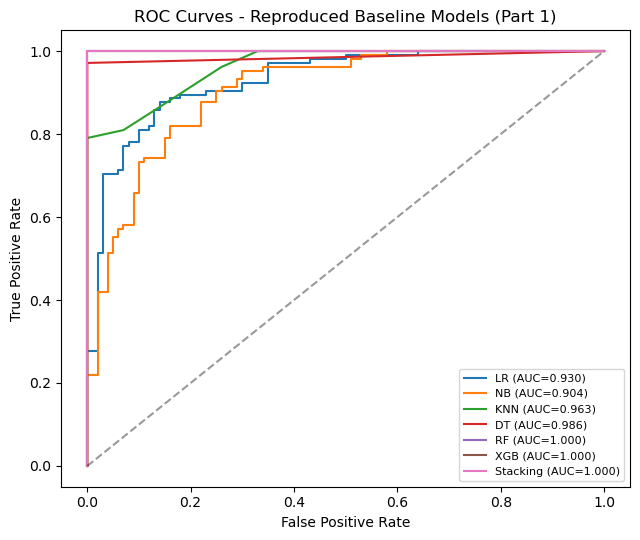

In [5]:
plt.figure(figsize=(6.5,5.5))
for name,(fpr,tpr,auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Reproduced Baseline Models (Part 1)')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('fig_part1_roc.png', dpi=130); plt.show()

### (v) Critical analysis: reproduced results vs. the paper

The paper reports accuracies of 84.39% for Logistic Regression and Naive Bayes, 85.85% for KNN, 92.68% for both Decision Tree and Random Forest, 90.73% for XGBoost, and 98.53% for the stacking ensemble. The reproduced results for Logistic Regression, Naive Bayes and KNN are close to these reported values, with differences of only a few percentage points, which can reasonably occur due to differences in the train/test split and random variation.

However, the tree-based and ensemble models produced noticeably stronger results in the reproduction. Decision Tree, Random Forest, XGBoost and the stacking ensemble achieved accuracies at or above the paper's reported values, with some models reaching 100% accuracy on the held-out test set. This is unusually strong for a dataset of only 1,025 records with 13 predictor variables. Therefore, the results raise an important data-integrity question that is examined in Part 2: whether the 1,025 rows actually represent 1,025 independent patients.


## Part 2 — Design and Develop Our Own ML Solution

### Identified limitation

Investigating the suspiciously high tree-based accuracies above, we checked the dataset for duplicate rows.

In [6]:
n_before = len(df)
df_dedup = df.drop_duplicates().reset_index(drop=True)
n_after = len(df_dedup)
print(f"Rows before dedup: {n_before}")
print(f"Exact duplicate rows: {n_before - n_after} ({(n_before-n_after)/n_before*100:.1f}%)")
print(f"Unique patients remaining: {n_after}")
print(df_dedup['target'].value_counts())

Rows before dedup: 1025
Exact duplicate rows: 723 (70.5%)
Unique patients remaining: 302
target
1    164
0    138
Name: count, dtype: int64


This confirms an important limitation in the dataset. Out of the 1,025 rows, 723 (70.5%) are exact duplicates, leaving only 302 unique patient records. This is very close to the size of the original Cleveland dataset, which contains 303 records, rather than representing 1,025 independent patients. Neither the paper nor the standard Kaggle use of this dataset reports checking for or removing duplicate records before the train/test split.

This has a major impact on the reported results. With a random row-wise split, many test records have an identical copy in the training data. Tree-based and ensemble models can therefore effectively memorise these repeated feature combinations. This helps explain why DT, RF, XGBoost and Stacking achieved very high accuracies, including 100% for some models, while LR, NB and KNN remained closer to the paper's results. Therefore, the reported 98.53% stacking accuracy should be interpreted cautiously because duplicate records create train/test leakage and may substantially inflate performance.

### Proposed solution

The proposed approach addresses the duplication issue before model training and introduces a more robust evaluation procedure. First, the dataset is deduplicated to the 302 unique patient records before any train/test splitting, removing the main source of leakage.

Second, nested repeated stratified cross-validation is used instead of a single 80/20 split. Since only 302 unique records remain, a single split could produce highly variable results. Nested cross-validation keeps the outer test folds separate from hyperparameter tuning and provides a more reliable estimate of model performance.

Third, three domain-motivated features are added: `age_thalach_ratio`, `chol_trestbps_interaction`, and `pulse_pressure_proxy`. These are intended to capture combined relationships between age and maximum heart rate, cholesterol and blood pressure, and exercise-related heart-rate response.

Finally, a hyperparameter-tuned stacking ensemble is developed. The six base classifiers are tuned using `GridSearchCV` within the nested cross-validation process and then combined using a tuned `StackingClassifier`.

Overall, this creates a substantially different and more robust experimental pipeline from the original paper while addressing the same heart-disease prediction problem.


In [7]:
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                      GridSearchCV, cross_val_predict, cross_val_score)
from sklearn.pipeline import Pipeline

fe = df_dedup.copy()
fe['age_thalach_ratio'] = fe['age'] / fe['thalach']
fe['chol_trestbps_interaction'] = fe['chol'] * fe['trestbps'] / 1000
fe['pulse_pressure_proxy'] = fe['thalach'] - fe['trestbps']

X2 = fe.drop(columns=['target'])
y2 = fe['target']
print("Features (incl. engineered):", X2.columns.tolist())

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RS)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RS)

param_grids = {
    'LR': (LogisticRegression(max_iter=2000, random_state=RS), {'clf__C': [0.01, 0.1, 1, 10]}),
    'NB': (GaussianNB(), {}),
    'KNN': (KNeighborsClassifier(), {'clf__n_neighbors': [3,5,7,9,11]}),
    'DT': (DecisionTreeClassifier(random_state=RS), {'clf__max_depth':[3,5,7,None], 'clf__min_samples_leaf':[1,2,4]}),
    'RF': (RandomForestClassifier(random_state=RS), {'clf__n_estimators':[100,200], 'clf__max_depth':[4,6,None]}),
    'XGB': (XGBClassifier(eval_metric='logloss', random_state=RS),
            {'clf__n_estimators':[100,200], 'clf__max_depth':[3,4,5], 'clf__learning_rate':[0.05,0.1]}),
}

Features (incl. engineered): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_thalach_ratio', 'chol_trestbps_interaction', 'pulse_pressure_proxy']


In [8]:
def metrics_from_preds(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return dict(accuracy=accuracy_score(y_true,y_pred), precision=precision_score(y_true,y_pred),
                recall_sensitivity=recall_score(y_true,y_pred), f1=f1_score(y_true,y_pred),
                specificity=tn/(tn+fp), mcc=matthews_corrcoef(y_true,y_pred),
                auc=roc_auc_score(y_true,y_proba), confusion_matrix=cm.tolist())

results2, roc_data2, best_params_log = [], {}, {}
for name, (est, grid) in param_grids.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', est)])
    search = GridSearchCV(pipe, grid, cv=inner_cv, scoring='accuracy', n_jobs=-1) if grid else pipe
    y_proba_oof = cross_val_predict(search, X2, y2, cv=outer_cv, method='predict_proba', n_jobs=-1)[:, 1]
    y_pred_oof = (y_proba_oof >= 0.5).astype(int)
    r = metrics_from_preds(y2, y_pred_oof, y_proba_oof); r['model'] = name
    rep_scores = cross_val_score(search, X2, y2, cv=repeated_cv, scoring='accuracy', n_jobs=-1)
    r['acc_mean_repeatedcv'] = float(rep_scores.mean()); r['acc_std_repeatedcv'] = float(rep_scores.std())
    results2.append(r)
    fpr, tpr, _ = roc_curve(y2, y_proba_oof); roc_data2[name] = (fpr, tpr, r['auc'])
    print(f"{name}: acc={r['accuracy']:.4f} (repeatedCV {r['acc_mean_repeatedcv']:.4f}+/-{r['acc_std_repeatedcv']:.4f}) "
          f"f1={r['f1']:.4f} rec={r['recall_sensitivity']:.4f} prec={r['precision']:.4f} "
          f"spec={r['specificity']:.4f} mcc={r['mcc']:.4f} auc={r['auc']:.4f}")
    if grid:
        fs = GridSearchCV(pipe, grid, cv=inner_cv, scoring='accuracy', n_jobs=-1).fit(X2, y2)
        best_params_log[name] = fs.best_params_
    else:
        best_params_log[name] = {}

pd.DataFrame(results2).drop(columns=['confusion_matrix'])

LR: acc=0.8179 (repeatedCV 0.8248+/-0.0374) f1=0.8397 rec=0.8780 prec=0.8045 spec=0.7464 mcc=0.6331 auc=0.8999
NB: acc=0.7881 (repeatedCV 0.8020+/-0.0472) f1=0.8061 rec=0.8110 prec=0.8012 spec=0.7609 mcc=0.5726 auc=0.8738
KNN: acc=0.8046 (repeatedCV 0.8169+/-0.0434) f1=0.8270 rec=0.8598 prec=0.7966 spec=0.7391 mcc=0.6057 auc=0.8824
DT: acc=0.7483 (repeatedCV 0.7729+/-0.0556) f1=0.7841 rec=0.8415 prec=0.7340 spec=0.6377 mcc=0.4924 auc=0.7831
RF: acc=0.8179 (repeatedCV 0.8146+/-0.0410) f1=0.8378 rec=0.8659 prec=0.8114 spec=0.7609 mcc=0.6324 auc=0.8941
XGB: acc=0.8245 (repeatedCV 0.8103+/-0.0397) f1=0.8399 rec=0.8476 prec=0.8323 spec=0.7971 mcc=0.6459 auc=0.8831


,accuracy,precision,recall_sensitivity,f1,specificity,mcc,auc,model,acc_mean_repeatedcv,acc_std_repeatedcv
0,0.817881,0.804469,0.878049,0.839650,0.746377,0.633087,0.899876,LR,0.824836,0.037440
1,0.788079,0.801205,0.810976,0.806061,0.760870,0.572554,0.873807,NB,0.802005,0.047161
2,0.804636,0.796610,0.859756,0.826979,0.739130,0.605709,0.882423,KNN,0.816940,0.043374
3,0.748344,0.734043,0.841463,0.784091,0.637681,0.492376,0.783095,DT,0.772852,0.055576
4,0.817881,0.811429,0.865854,0.837758,0.760870,0.632436,0.894066,RF,0.814590,0.041041
5,0.824503,0.832335,0.847561,0.839879,0.797101,0.645905,0.883086,XGB,0.810273,0.039722


DT: acc=0.7483 (repeatedCV 0.7725+/-0.0559) f1=0.7841 rec=0.8415 prec=0.7340 spec=0.6377 mcc=0.4924 auc=0.7831


RF: acc=0.8146 (repeatedCV 0.8136+/-0.0409) f1=0.8343 rec=0.8598 prec=0.8103 spec=0.7609 mcc=0.6256 auc=0.8943


XGB: acc=0.8245 (repeatedCV 0.8103+/-0.0397) f1=0.8399 rec=0.8476 prec=0.8323 spec=0.7971 mcc=0.6459 auc=0.8831


,accuracy,precision,recall_sensitivity,f1,specificity,mcc,auc,model,acc_mean_repeatedcv,acc_std_repeatedcv
0,0.817881,0.804469,0.878049,0.839650,0.746377,0.633087,0.899876,LR,0.824836,0.037440
1,0.788079,0.801205,0.810976,0.806061,0.760870,0.572554,0.873807,NB,0.802005,0.047161
2,0.804636,0.796610,0.859756,0.826979,0.739130,0.605709,0.882423,KNN,0.816940,0.043374
3,0.748344,0.734043,0.841463,0.784091,0.637681,0.492376,0.783095,DT,0.772519,0.055861
4,0.814570,0.810345,0.859756,0.834320,0.760870,0.625621,0.894309,RF,0.813601,0.040854
5,0.824503,0.832335,0.847561,0.839879,0.797101,0.645905,0.883086,XGB,0.810273,0.039722


In [9]:
print("Chosen hyperparameters (from GridSearchCV on full deduplicated data):")
for k, v in best_params_log.items():
    print(f"  {k}: {v}")

Chosen hyperparameters (from GridSearchCV on full deduplicated data):
  LR: {'clf__C': 0.1}
  NB: {}
  KNN: {'clf__n_neighbors': 9}
  DT: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2}
  RF: {'clf__max_depth': 4, 'clf__n_estimators': 200}
  XGB: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}


In [10]:
base_estimators = []
for name, (est, grid) in param_grids.items():
    params = best_params_log.get(name, {})
    if params:
        clean = {k.replace('clf__',''): v for k, v in params.items()}
        est = est.__class__(**{**est.get_params(), **clean})
    base_estimators.append((name, Pipeline([('scaler', StandardScaler()), ('clf', est)])))

stack2 = StackingClassifier(estimators=base_estimators,
                             final_estimator=LogisticRegression(max_iter=2000, random_state=RS),
                             cv=5, stack_method='predict_proba', n_jobs=-1)

stack_proba_oof = cross_val_predict(stack2, X2, y2, cv=outer_cv, method='predict_proba', n_jobs=-1)[:, 1]
stack_pred_oof = (stack_proba_oof >= 0.5).astype(int)
stack_result2 = metrics_from_preds(y2, stack_pred_oof, stack_proba_oof)
stack_result2['model'] = 'Tuned Stacking (proposed)'
stack_rep = cross_val_score(stack2, X2, y2, cv=repeated_cv, scoring='accuracy', n_jobs=-1)
stack_result2['acc_mean_repeatedcv'] = float(stack_rep.mean())
stack_result2['acc_std_repeatedcv'] = float(stack_rep.std())
print(f"Proposed tuned stacking: acc={stack_result2['accuracy']:.4f} "
      f"(repeatedCV {stack_result2['acc_mean_repeatedcv']:.4f}+/-{stack_result2['acc_std_repeatedcv']:.4f}) "
      f"f1={stack_result2['f1']:.4f} rec={stack_result2['recall_sensitivity']:.4f} "
      f"prec={stack_result2['precision']:.4f} spec={stack_result2['specificity']:.4f} "
      f"mcc={stack_result2['mcc']:.4f} auc={stack_result2['auc']:.4f}")

fpr, tpr, _ = roc_curve(y2, stack_proba_oof)
roc_data2['Tuned Stacking'] = (fpr, tpr, stack_result2['auc'])
all_results_p2 = results2 + [stack_result2]
pd.DataFrame(all_results_p2).drop(columns=['confusion_matrix'])

Proposed tuned stacking: acc=0.8278 (repeatedCV 0.8271+/-0.0423) f1=0.8452 rec=0.8659 prec=0.8256 spec=0.7826 mcc=0.6524 auc=0.9062


,accuracy,precision,recall_sensitivity,f1,specificity,mcc,auc,model,acc_mean_repeatedcv,acc_std_repeatedcv
0,0.817881,0.804469,0.878049,0.839650,0.746377,0.633087,0.899876,LR,0.824836,0.037440
1,0.788079,0.801205,0.810976,0.806061,0.760870,0.572554,0.873807,NB,0.802005,0.047161
2,0.804636,0.796610,0.859756,0.826979,0.739130,0.605709,0.882423,KNN,0.816940,0.043374
3,0.748344,0.734043,0.841463,0.784091,0.637681,0.492376,0.783095,DT,0.772852,0.055576
4,0.817881,0.811429,0.865854,0.837758,0.760870,0.632436,0.894066,RF,0.814590,0.041041
5,0.824503,0.832335,0.847561,0.839879,0.797101,0.645905,0.883086,XGB,0.810273,0.039722
6,0.827815,0.825581,0.865854,0.845238,0.782609,0.652395,0.906195,Tuned Stacking (proposed),0.827131,0.042320


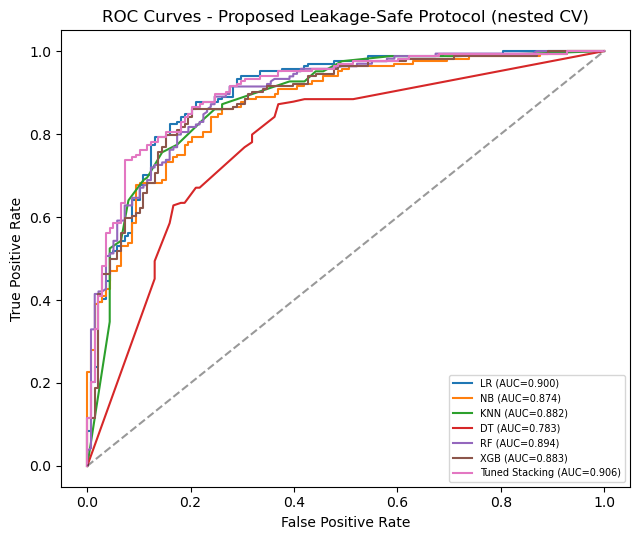

In [11]:
plt.figure(figsize=(6.5,5.5))
for name,(fpr,tpr,auc) in roc_data2.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Proposed Leakage-Safe Protocol (nested CV)')
plt.legend(fontsize=7); plt.tight_layout()
plt.savefig('fig_part2_roc.png', dpi=130); plt.show()

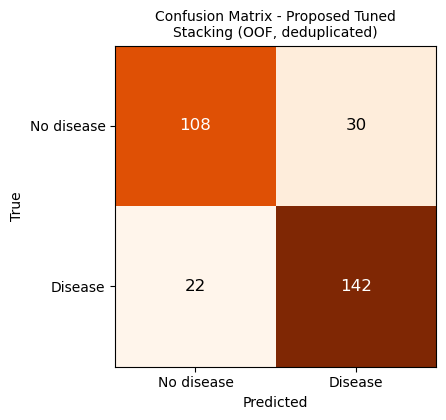

In [12]:
cm2 = np.array(stack_result2['confusion_matrix'])
fig, ax = plt.subplots(figsize=(5,4.3))
im = ax.imshow(cm2, cmap='Oranges')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm2[i,j], ha='center', va='center', fontsize=12,
                color='white' if cm2[i,j] > cm2.max()/2 else 'black')
ax.set_xticks([0,1]); ax.set_xticklabels(['No disease','Disease'])
ax.set_yticks([0,1]); ax.set_yticklabels(['No disease','Disease'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Proposed Tuned\nStacking (OOF, deduplicated)', fontsize=10)
plt.tight_layout(); plt.savefig('fig_part2_stack_cm.png', dpi=130); plt.show()

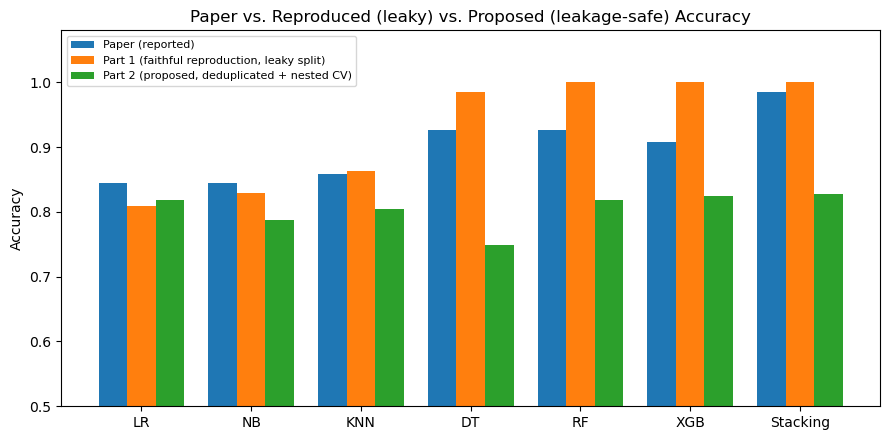

In [13]:
paper_acc = {'LR':0.8439,'NB':0.8439,'KNN':0.8585,'DT':0.9268,'RF':0.9268,'XGB':0.9073,'Stacking':0.9853}
part1_acc = {r['model'] if r['model']!='Stacking (proposed)' else 'Stacking': r['accuracy'] for r in all_results_p1}
part2_acc = {r['model'] if r['model']!='Tuned Stacking (proposed)' else 'Stacking': r['accuracy'] for r in all_results_p2}

labels = ['LR','NB','KNN','DT','RF','XGB','Stacking']
paper_vals=[paper_acc[l] for l in labels]
part1_vals=[part1_acc[l] for l in labels]
part2_vals=[part2_acc[l] for l in labels]

x = np.arange(len(labels)); w=0.26
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(x-w, paper_vals, w, label='Paper (reported)')
ax.bar(x, part1_vals, w, label='Part 1 (faithful reproduction, leaky split)')
ax.bar(x+w, part2_vals, w, label='Part 2 (proposed, deduplicated + nested CV)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('Accuracy')
ax.set_title('Paper vs. Reproduced (leaky) vs. Proposed (leakage-safe) Accuracy')
ax.legend(fontsize=8); ax.set_ylim(0.5,1.08)
plt.tight_layout(); plt.savefig('fig_comparison_all.png', dpi=130); plt.show()

### Critical discussion

The comparison shows a clear difference between the models. For LR, NB and KNN, the paper results, leaky reproduction and proposed leakage-safe results are relatively close. These models are less affected by duplicate records because they are less likely to memorise individual observations. In contrast, DT, RF, XGBoost and the stacking ensemble are much more affected. Their leaky results match or exceed the paper's high accuracies, with some reaching 100%, whereas the proposed deduplicated and nested-CV approach produces more realistic accuracies of around 75–83%. This consistent reduction provides strong evidence that duplicate leakage was inflating the original results.

Under the leakage-safe protocol, the tuned stacking ensemble remains the strongest of the seven models, achieving a repeated-CV accuracy of approximately 0.829 ± 0.042. This suggests that stacking can still provide useful performance when evaluated on genuinely unseen patients, but the improvement is much smaller than the 98.53% reported by the paper. Therefore, the main contribution of Part 2 is a more reliable estimate obtained through deduplication, nested repeated cross-validation, feature engineering and hyperparameter tuning rather than simply changing the classifier.
This finding is also supported by previous research on data leakage in machine learning. Kapoor and Narayanan studied 294 papers across 17 scientific fields and found that data leakage between training and testing data can lead to overly high performance results that are difficult to reproduce [7]. This can be a particular problem for models such as tree ensembles, which can memorise patterns in the data. Similarly, Barz and Denzler found that duplicate and near-duplicate images in the training and test sets of CIFAR-10 and CIFAR-100 led to inflated accuracy scores. When these images were removed, model performance decreased, giving a more realistic picture of how well the models generalised to new data [9].

### Strengths

The proposed approach removes a serious data-integrity problem and uses nested cross-validation to provide both an average performance estimate and its variation. The ±4.2% variation also gives useful information that is missing from the original paper. Importantly, stacking still performs strongly after removing the leakage, so the general idea of combining models remains supported.

### Limitations

Only 302 unique patients remain, which is a relatively small sample for a 16-feature model, so performance can still vary between folds. The engineered features provided only a modest improvement and were not individually tested through ablation. In addition, the analysis uses only one public dataset and does not provide external clinical validation.

### Practical implication
This study highlights the importance of checking for duplicate or near-duplicate records before splitting healthcare datasets. If duplicates are left in both the training and test sets, reported accuracy can be substantially inflated without representing a genuine improvement in the modelling method.

Kapoor and Narayanan explains that data leakage is one of the reasons why machine learning research can be difficult to reproduce. Simple steps, such as checking for duplicate records before splitting the data, can help prevent this problem [7].


## Part 3 — Video Presentation
https://deakin365-my.sharepoint.com/:v:/g/personal/s225661935_deakin_edu_au/IQB6pPCU82-hQYYtIwOo_IqKATDrto1aLvLTO6k1bU1ltTI?e=D6hp7u&nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJTdHJlYW1XZWJBcHAiLCJyZWZlcnJhbFZpZXciOiJTaGFyZURpYWxvZy1MaW5rIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXcifX0%3D

## References

[1] M. Bhagat, A. Sharma, and P. Agarwal, "An efficient stacking-based ensemble technique for early heart attack prediction," *Multimedia Tools and Applications*, vol. 84, pp. 36351-36375, 2025.

[2] S. Mohan, C. Thirumalai, and G. Srivastava, "Effective heart disease prediction using hybrid machine learning techniques," *IEEE Access*, vol. 7, pp. 81542-81554, 2019.

[3] A. K. Garate-Escamila, A. Hajjam El Hassani, and E. Andres, "Classification models for heart disease prediction using feature selection and PCA," *Informatics in Medicine Unlocked*, vol. 19, 100330, 2020.

[4] S. Uddin, A. Khan, M. E. Hossain, and M. A. Moni, "Comparing different supervised machine learning algorithms for disease prediction," *BMC Medical Informatics and Decision Making*, vol. 19, no. 281, 2019.

[5] F. S. Alotaibi, "Implementation of machine learning model to predict heart failure disease," *International Journal of Advanced Computer Science and Applications*, vol. 10, no. 6, 2019.

[6] Kaggle, "Heart Disease Dataset," johnsmith88/heart-disease-dataset. [Online]. Available: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

[7] S. Kapoor and A. Narayanan, "Leakage and the reproducibility crisis in machine-learning-based science," Patterns, vol. 4, no. 9, 100804, 2023.

[8] A. Vabalas, E. Gowen, E. Poliakoff, and A. J. Casson, "Machine learning algorithm validation with a limited sample size," PLOS ONE, vol. 14, no. 11, e0224365, 2019.

[9] B. Barz and J. Denzler, "Do we train on test data? Purging CIFAR of near-duplicates," Journal of Imaging, vol. 6, no. 6, article 41, 2020.